In [41]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [42]:
#Các thông số vật lý của hệ con lắc 
L1 = 1.0 #Chiều dài của dây treo con lắc 1 (đơn vị: mét)
L2 = 1.0 #Chiều dài của dây treo con lắc 2 (đơn vị: mét)
L3 = 1.0 #Chiều dài của dây treo con lắc 3 (đơn vị: mét)
L4 = 1.0 #Chiều dài của dây treo con lắc 4 (đơn vị: mét)
L5 = 1.0 #Chiều dài của dây treo con lắc 5 (đơn vị: mét)
m1 = 1.0 #Khối lượng của con lắc 1 (đơn vị: kg)
m2 = 1.0 #Khối lượng của con lắc 2 (đơn vị: kg)
m3 = 1.0 #Khối lượng của con lắc 3 (đơn vị: kg)
m4 = 1.0 #Khối lượng của con lắc 4 (đơn vị: kg)
m5 = 1.0 #Khối lượng của con lắc 5 (đơn vị: kg)
g = 9.81 #Gia tốc trọng trường (đơn vị: m/s^2)
end_time = 10 #Khoảng thời gian xét sự chuyển động của hệ con lắc kép
t = np.linspace(0, end_time, 50000) #Tạo mảng thời gian

In [43]:
def five_pendulum_ode(
    state, t,
    L1, L2, L3, L4, L5,
    m1, m2, m3, m4, m5,
    g
):

    theta1, omega1, theta2, omega2, theta3, omega3, theta4, omega4, theta5, omega5 = state

    d12 = theta1-theta2
    d13 = theta1-theta3
    d14 = theta1-theta4
    d15 = theta1-theta5

    d23 = theta2-theta3
    d24 = theta2-theta4
    d25 = theta2-theta5

    d34 = theta3-theta4
    d35 = theta3-theta5

    d45 = theta4-theta5

    # sin cos

    c12,s12=np.cos(d12),np.sin(d12)
    c13,s13=np.cos(d13),np.sin(d13)
    c14,s14=np.cos(d14),np.sin(d14)
    c15,s15=np.cos(d15),np.sin(d15)

    c23,s23=np.cos(d23),np.sin(d23)
    c24,s24=np.cos(d24),np.sin(d24)
    c25,s25=np.cos(d25),np.sin(d25)

    c34,s34=np.cos(d34),np.sin(d34)
    c35,s35=np.cos(d35),np.sin(d35)

    c45,s45=np.cos(d45),np.sin(d45)

    eps = 1e-6 

    # MASS MATRIX

    M11=(m1+m2+m3+m4+m5)*L1**2
    M12=(m2+m3+m4+m5)*L1*L2*c12
    M13=(m3+m4+m5)*L1*L3*c13
    M14=(m4+m5)*L1*L4*c14
    M15=m5*L1*L5*c15

    M22=(m2+m3+m4+m5)*L2**2
    M23=(m3+m4+m5)*L2*L3*c23
    M24=(m4+m5)*L2*L4*c24
    M25=m5*L2*L5*c25

    M33=(m3+m4+m5)*L3**2
    M34=(m4+m5)*L3*L4*c34
    M35=m5*L3*L5*c35

    M44=(m4+m5)*L4**2
    M45=m5*L4*L5*c45

    M55=m5*L5**2

    M=np.array([
        [M11,M12,M13,M14,M15],
        [M12,M22,M23,M24,M25],
        [M13,M23,M33,M34,M35],
        [M14,M24,M34,M44,M45],
        [M15,M25,M35,M45,M55]
    ])

    # GRAVITY
    G=np.array([
        -(m1+m2+m3+m4+m5)*g*L1*np.sin(theta1),
        -(m2+m3+m4+m5)*g*L2*np.sin(theta2),
        -(m3+m4+m5)*g*L3*np.sin(theta3),
        -(m4+m5)*g*L4*np.sin(theta4),
        -m5*g*L5*np.sin(theta5)
    ])

    # CORIOLIS + CENTRIFUGAL
    C=np.array([

        -(m2+m3+m4+m5)*L1*L2*s12*omega2**2
        -(m3+m4+m5)*L1*L3*s13*omega3**2
        -(m4+m5)*L1*L4*s14*omega4**2
        -m5*L1*L5*s15*omega5**2,

        +(m2+m3+m4+m5)*L1*L2*s12*omega1**2
        -(m3+m4+m5)*L2*L3*s23*omega3**2
        -(m4+m5)*L2*L4*s24*omega4**2
        -m5*L2*L5*s25*omega5**2,

        +(m3+m4+m5)*L1*L3*s13*omega1**2
        +(m3+m4+m5)*L2*L3*s23*omega2**2
        -(m4+m5)*L3*L4*s34*omega4**2
        -m5*L3*L5*s35*omega5**2,

        +(m4+m5)*L1*L4*s14*omega1**2
        +(m4+m5)*L2*L4*s24*omega2**2
        +(m4+m5)*L3*L4*s34*omega3**2
        -m5*L4*L5*s45*omega5**2,

        +m5*L1*L5*s15*omega1**2
        +m5*L2*L5*s25*omega2**2
        +m5*L3*L5*s35*omega3**2
        +m5*L4*L5*s45*omega4**2

    ])

    ddtheta=np.linalg.solve(M,G+C)

    return [
        omega1,ddtheta[0],
        omega2,ddtheta[1],
        omega3,ddtheta[2],
        omega4,ddtheta[3],
        omega5,ddtheta[4]
    ]

In [44]:
import numpy as np
from scipy.integrate import odeint

initial_state_fp = [
    np.pi/4, 0,
    np.pi/4, 0,
    np.pi/4, 0,
    np.pi/4, 0,
    np.pi/4, 0
]

fp_solution = odeint(
    five_pendulum_ode,
    initial_state_fp,
    t,
    args=(
        L1, L2, L3, L4, L5,
        m1, m2, m3, m4, m5,
        g
    )
)

# Trích theta
theta1 = fp_solution[:, 0]
theta2 = fp_solution[:, 2]
theta3 = fp_solution[:, 4]
theta4 = fp_solution[:, 6]
theta5 = fp_solution[:, 8]

omega1 = fp_solution[:, 1]
omega2 = fp_solution[:, 3]
omega3 = fp_solution[:, 5]
omega4 = fp_solution[:, 7]
omega5 = fp_solution[:, 9]

theta_ode = np.column_stack([
    theta1,
    theta2,
    theta3,
    theta4,
    theta5
])

dtheta_ode = np.column_stack([
    omega1,
    omega2,
    omega3,
    omega4,
    omega5
])

ddtheta_ode = np.zeros((len(t), 5))

for i in range(len(t)):

    state = fp_solution[i]

    rhs = five_pendulum_ode(
        state,
        t[i],
        L1, L2, L3, L4, L5,
        m1, m2, m3, m4, m5,
        g
    )

    ddtheta_ode[i] = [
        rhs[1],
        rhs[3],
        rhs[5],
        rhs[7],
        rhs[9]
    ]

y_numerical = torch.tensor(
    theta_ode,
    dtype=torch.float32
) 

t_torch = torch.tensor(
    t,
    dtype=torch.float32
).view(-1,1)

x_data_fp = t_torch[:10000:1000]
y_data_fp = y_numerical[:10000:1000]

print("x_data_fp:", x_data_fp.shape)
print("y_data_fp:", y_data_fp.shape)


print("\n=== 5 PENDULUM ===")
print(f"Shape: {fp_solution.shape}")
print("theta_ode shape       =", theta_ode.shape)
print("dtheta_ode shape      =", dtheta_ode.shape)
print(f"theta1[:5]: {theta1[:5]}")
print(f"theta5[:5]: {theta5[:5]}")

x_data_fp: torch.Size([10, 1])
y_data_fp: torch.Size([10, 5])

=== 5 PENDULUM ===
Shape: (50000, 10)
theta_ode shape       = (50000, 5)
dtheta_ode shape      = (50000, 5)
theta1[:5]: [0.78539816 0.78539802 0.78539761 0.78539691 0.78539594]
theta5[:5]: [0.78539816 0.78539816 0.78539816 0.78539816 0.78539816]


In [45]:
def five_pendulum_physics_residuals(
    theta1, dtheta1, ddtheta1,
    theta2, dtheta2, ddtheta2,
    theta3, dtheta3, ddtheta3,
    theta4, dtheta4, ddtheta4,
    theta5, dtheta5, ddtheta5,
    L1, L2, L3, L4, L5,
    m1, m2, m3, m4, m5,
    g,
):

    #==========================
    # delta
    #==========================

    d12 = theta1-theta2
    d13 = theta1-theta3
    d14 = theta1-theta4
    d15 = theta1-theta5

    d23 = theta2-theta3
    d24 = theta2-theta4
    d25 = theta2-theta5

    d34 = theta3-theta4
    d35 = theta3-theta5

    d45 = theta4-theta5

    c12,s12=torch.cos(d12),torch.sin(d12)
    c13,s13=torch.cos(d13),torch.sin(d13)
    c14,s14=torch.cos(d14),torch.sin(d14)
    c15,s15=torch.cos(d15),torch.sin(d15)

    c23,s23=torch.cos(d23),torch.sin(d23)
    c24,s24=torch.cos(d24),torch.sin(d24)
    c25,s25=torch.cos(d25),torch.sin(d25)

    c34,s34=torch.cos(d34),torch.sin(d34)
    c35,s35=torch.cos(d35),torch.sin(d35)

    c45,s45=torch.cos(d45),torch.sin(d45)

    #==========================
    # Mass matrix
    #==========================

    M11=(m1+m2+m3+m4+m5)*L1**2
    M12=(m2+m3+m4+m5)*L1*L2*c12
    M13=(m3+m4+m5)*L1*L3*c13
    M14=(m4+m5)*L1*L4*c14
    M15=m5*L1*L5*c15

    M22=(m2+m3+m4+m5)*L2**2
    M23=(m3+m4+m5)*L2*L3*c23
    M24=(m4+m5)*L2*L4*c24
    M25=m5*L2*L5*c25

    M33=(m3+m4+m5)*L3**2
    M34=(m4+m5)*L3*L4*c34
    M35=m5*L3*L5*c35

    M44=(m4+m5)*L4**2
    M45=m5*L4*L5*c45

    M55=m5*L5**2

    #==========================
    # Gravity
    #==========================

    G1=-(m1+m2+m3+m4+m5)*g*L1*torch.sin(theta1)
    G2=-(m2+m3+m4+m5)*g*L2*torch.sin(theta2)
    G3=-(m3+m4+m5)*g*L3*torch.sin(theta3)
    G4=-(m4+m5)*g*L4*torch.sin(theta4)
    G5=-m5*g*L5*torch.sin(theta5)

    #==========================
    # Coriolis
    #==========================

    C1=(
        -(m2+m3+m4+m5)*L1*L2*s12*dtheta2**2
        -(m3+m4+m5)*L1*L3*s13*dtheta3**2
        -(m4+m5)*L1*L4*s14*dtheta4**2
        -m5*L1*L5*s15*dtheta5**2
    )

    C2=(
        +(m2+m3+m4+m5)*L1*L2*s12*dtheta1**2
        -(m3+m4+m5)*L2*L3*s23*dtheta3**2
        -(m4+m5)*L2*L4*s24*dtheta4**2
        -m5*L2*L5*s25*dtheta5**2
    )

    C3=(
        +(m3+m4+m5)*L1*L3*s13*dtheta1**2
        +(m3+m4+m5)*L2*L3*s23*dtheta2**2
        -(m4+m5)*L3*L4*s34*dtheta4**2
        -m5*L3*L5*s35*dtheta5**2
    )

    C4=(
        +(m4+m5)*L1*L4*s14*dtheta1**2
        +(m4+m5)*L2*L4*s24*dtheta2**2
        +(m4+m5)*L3*L4*s34*dtheta3**2
        -m5*L4*L5*s45*dtheta5**2
    )

    C5=(
        +m5*L1*L5*s15*dtheta1**2
        +m5*L2*L5*s25*dtheta2**2
        +m5*L3*L5*s35*dtheta3**2
        +m5*L4*L5*s45*dtheta4**2
    )

    #==========================
    # Residual
    #==========================

    r1 = (
        M11*ddtheta1 + M12*ddtheta2 + M13*ddtheta3 + M14*ddtheta4 + M15*ddtheta5
        - G1 - C1
    )

    r2 = (
        M12*ddtheta1 + M22*ddtheta2 + M23*ddtheta3 + M24*ddtheta4 + M25*ddtheta5
        - G2 - C2
    )

    r3 = (
        M13*ddtheta1 + M23*ddtheta2 + M33*ddtheta3 + M34*ddtheta4 + M35*ddtheta5
        - G3 - C3
    )

    r4 = (
        M14*ddtheta1 + M24*ddtheta2 + M34*ddtheta3 + M44*ddtheta4 + M45*ddtheta5
        - G4 - C4
    )

    r5 = (
        M15*ddtheta1 + M25*ddtheta2 + M35*ddtheta3 + M45*ddtheta4 + M55*ddtheta5
        - G5 - C5
    )

    return r1, r2, r3, r4, r5

In [46]:
# FCN class definition
class FCN(nn.Module):
    "Defines a connected network"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = torch.cat(
            [x, 
            x**2,
            torch.sin(x), 
            torch.cos(x), 
            torch.sin(2*x), 
            torch.cos(2*x),
            torch.sin(3*x),
            torch.cos(3*x),
            torch.sin(4*x),
            torch.cos(4*x),
            torch.sin(5*x),
            torch.cos(5*x),
            torch.sin(10*x),
            torch.cos(10*x)
        ],dim=1)
        
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

In [47]:
def five_pendulum_energy(theta1, dtheta1,
                         theta2, dtheta2,
                         theta3, dtheta3,
                         theta4, dtheta4,
                         theta5, dtheta5,
                         L1, L2, L3, L4, L5,
                         m1, m2, m3, m4, m5,
                         g):

    # ===== KINETIC =====
    kinetic = (
        0.5*(m1+m2+m3+m4+m5)*L1**2*dtheta1**2
        + 0.5*(m2+m3+m4+m5)*L2**2*dtheta2**2
        + 0.5*(m3+m4+m5)*L3**2*dtheta3**2
        + 0.5*(m4+m5)*L4**2*dtheta4**2
        + 0.5*m5*L5**2*dtheta5**2

        + (m2+m3+m4+m5)*L1*L2*dtheta1*dtheta2*torch.cos(theta1-theta2)
        + (m3+m4+m5)*L1*L3*dtheta1*dtheta3*torch.cos(theta1-theta3)
        + (m4+m5)*L1*L4*dtheta1*dtheta4*torch.cos(theta1-theta4)
        + m5*L1*L5*dtheta1*dtheta5*torch.cos(theta1-theta5)

        + (m3+m4+m5)*L2*L3*dtheta2*dtheta3*torch.cos(theta2-theta3)
        + (m4+m5)*L2*L4*dtheta2*dtheta4*torch.cos(theta2-theta4)
        + m5*L2*L5*dtheta2*dtheta5*torch.cos(theta2-theta5)

        + (m4+m5)*L3*L4*dtheta3*dtheta4*torch.cos(theta3-theta4)
        + m5*L3*L5*dtheta3*dtheta5*torch.cos(theta3-theta5)

        + m5*L4*L5*dtheta4*dtheta5*torch.cos(theta4-theta5)
    )

    # ===== POTENTIAL =====
    potential = (
        -(m1+m2+m3+m4+m5)*g*L1*torch.cos(theta1)
        -(m2+m3+m4+m5)*g*L2*torch.cos(theta2)
        -(m3+m4+m5)*g*L3*torch.cos(theta3)
        -(m4+m5)*g*L4*torch.cos(theta4)
        -m5*g*L5*torch.cos(theta5)
    )

    return kinetic + potential

In [48]:
def plot_result_five_pendulum(
    x,
    theta_numerical,
    yh,
    x_data=None,
    y_data=None
):
    """
    theta_numerical : numpy array (N,5)
    yh              : torch tensor (N,5)
    """

    plt.figure(figsize=(12, 6))

    # ===== Convert once =====
    x_np = x.detach().cpu().numpy().reshape(-1)
    yh_np = yh.detach().cpu().numpy()

    if y_data is not None:
        x_data_np = x_data.detach().cpu().numpy().reshape(-1)
        y_data_np = y_data.detach().cpu().numpy()

        assert x_data_np.shape[0] == y_data_np.shape[0], (
            f"Mismatch: x_data {x_data_np.shape} vs y_data {y_data_np.shape}"
        )

    titles = [
        "Theta1",
        "Theta2",
        "Theta3",
        "Theta4",
        "Theta5"
    ]

    for i in range(5):

        plt.subplot(1, 5, i + 1)

        # Numerical solution
        plt.plot(
            x_np,
            theta_numerical[:, i],
            'o',
            color="red",
            alpha=0.7,
            markersize=0.4,
            label="ODE"
        )

        # PINN prediction
        plt.plot(
            x_np,
            yh_np[:, i],
            color="blue",
            linewidth=1,
            label="PINN"
        )

        # Training data
        if y_data is not None:
            plt.scatter(
                x_data_np,
                y_data_np[:, i],
                color="green",
                s=20,
                label="Data"
            )

        plt.title(titles[i])
        plt.grid(True)

        # Chỉ hiện legend ở subplot đầu tiên
        if i == 0:
            plt.legend()

    plt.tight_layout()

Iteration 1000, Loss_data: 0.353889, Loss_physics: 0.230899, Loss_ic: 0.472066, Loss_energy: 0.000023, Total Loss: 262.661865
Iteration 2000, Loss_data: 0.404651, Loss_physics: 0.210076, Loss_ic: 0.547665, Loss_energy: 0.000011, Total Loss: 298.886414
Iteration 3000, Loss_data: 0.361721, Loss_physics: 0.201336, Loss_ic: 0.474773, Loss_energy: 0.000026, Total Loss: 261.137482
Iteration 4000, Loss_data: 0.368680, Loss_physics: 0.144375, Loss_ic: 0.491065, Loss_energy: 0.000018, Total Loss: 263.657013
Iteration 5000, Loss_data: 0.276164, Loss_physics: 0.344843, Loss_ic: 0.341656, Loss_energy: 0.000128, Total Loss: 208.074142


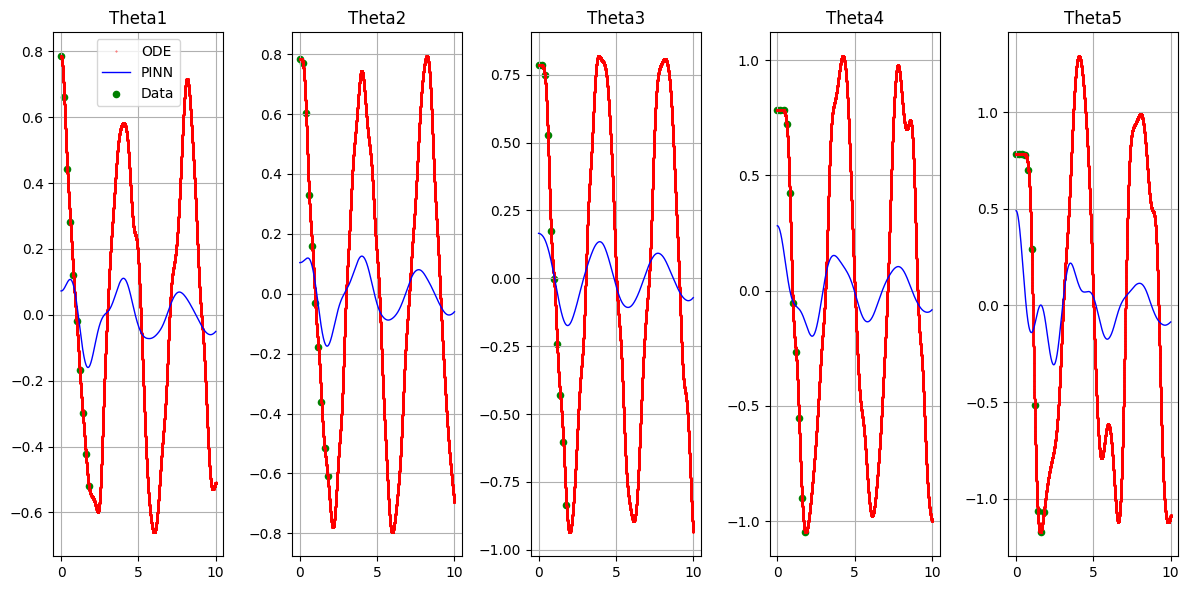

Iteration 6000, Loss_data: 0.355693, Loss_physics: 0.182232, Loss_ic: 0.466693, Loss_energy: 0.000028, Total Loss: 255.126663
Iteration 7000, Loss_data: 0.364210, Loss_physics: 0.104381, Loss_ic: 0.510987, Loss_energy: 0.000006, Total Loss: 269.573517
Iteration 8000, Loss_data: 0.094912, Loss_physics: 0.173647, Loss_ic: 0.104861, Loss_energy: 0.000230, Total Loss: 70.744537
Iteration 9000, Loss_data: 0.065126, Loss_physics: 0.749037, Loss_ic: 0.075912, Loss_energy: 0.000080, Total Loss: 113.510818
Iteration 10000, Loss_data: 0.034922, Loss_physics: 0.255176, Loss_ic: 0.037157, Loss_energy: 0.000061, Total Loss: 44.445236


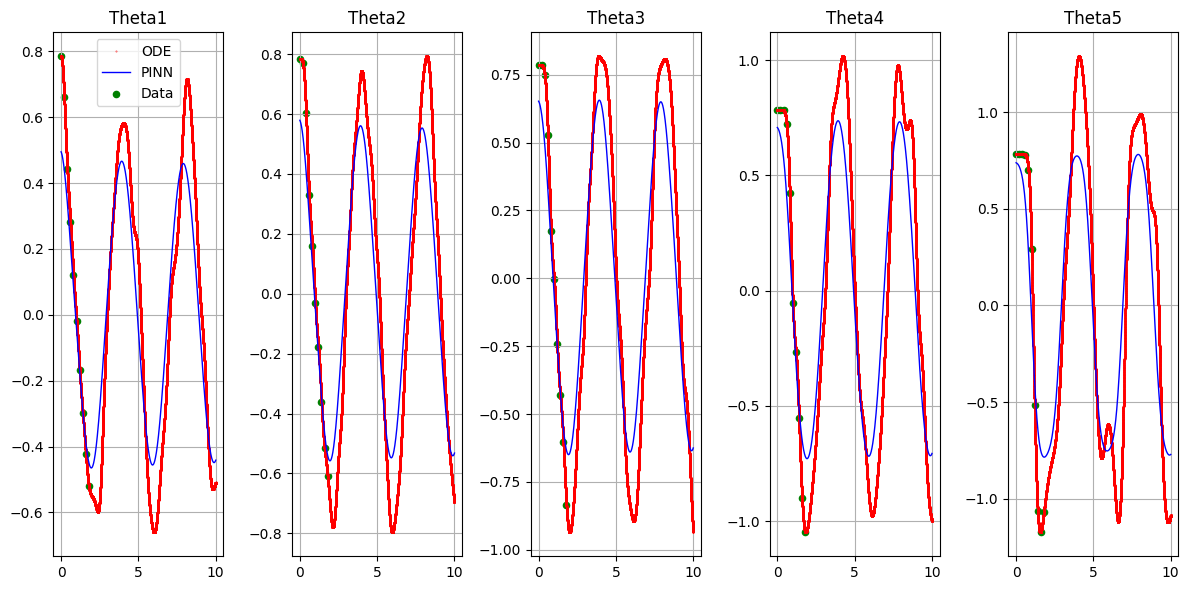

Iteration 11000, Loss_data: 0.026052, Loss_physics: 0.174113, Loss_ic: 0.026304, Loss_energy: 0.000046, Total Loss: 30.824005
Iteration 12000, Loss_data: 0.020693, Loss_physics: 0.049137, Loss_ic: 0.019468, Loss_energy: 0.000045, Total Loss: 14.854880
Iteration 13000, Loss_data: 0.018298, Loss_physics: 0.088160, Loss_ic: 0.016528, Loss_energy: 0.000043, Total Loss: 17.263113
Iteration 14000, Loss_data: 0.015361, Loss_physics: 0.031270, Loss_ic: 0.013285, Loss_energy: 0.000034, Total Loss: 9.922972
Iteration 15000, Loss_data: 0.014326, Loss_physics: 0.028388, Loss_ic: 0.012336, Loss_energy: 0.000027, Total Loss: 9.150055


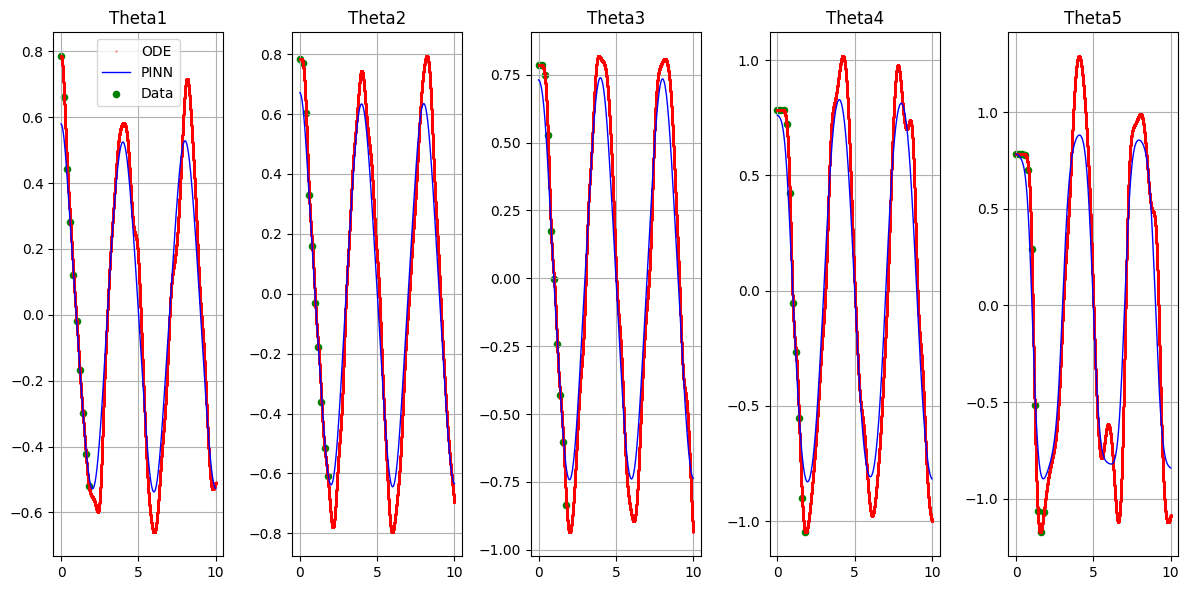

Iteration 16000, Loss_data: 0.012034, Loss_physics: 0.049356, Loss_ic: 0.009977, Loss_energy: 0.000029, Total Loss: 10.044516
Iteration 17000, Loss_data: 0.011008, Loss_physics: 0.082752, Loss_ic: 0.008900, Loss_energy: 0.000029, Total Loss: 12.835406
Iteration 18000, Loss_data: 0.009305, Loss_physics: 0.068112, Loss_ic: 0.007107, Loss_energy: 0.000023, Total Loss: 10.457738
Iteration 19000, Loss_data: 0.008804, Loss_physics: 0.044324, Loss_ic: 0.006727, Loss_energy: 0.000024, Total Loss: 7.884110
Iteration 20000, Loss_data: 0.008195, Loss_physics: 0.035798, Loss_ic: 0.006368, Loss_energy: 0.000017, Total Loss: 6.845877


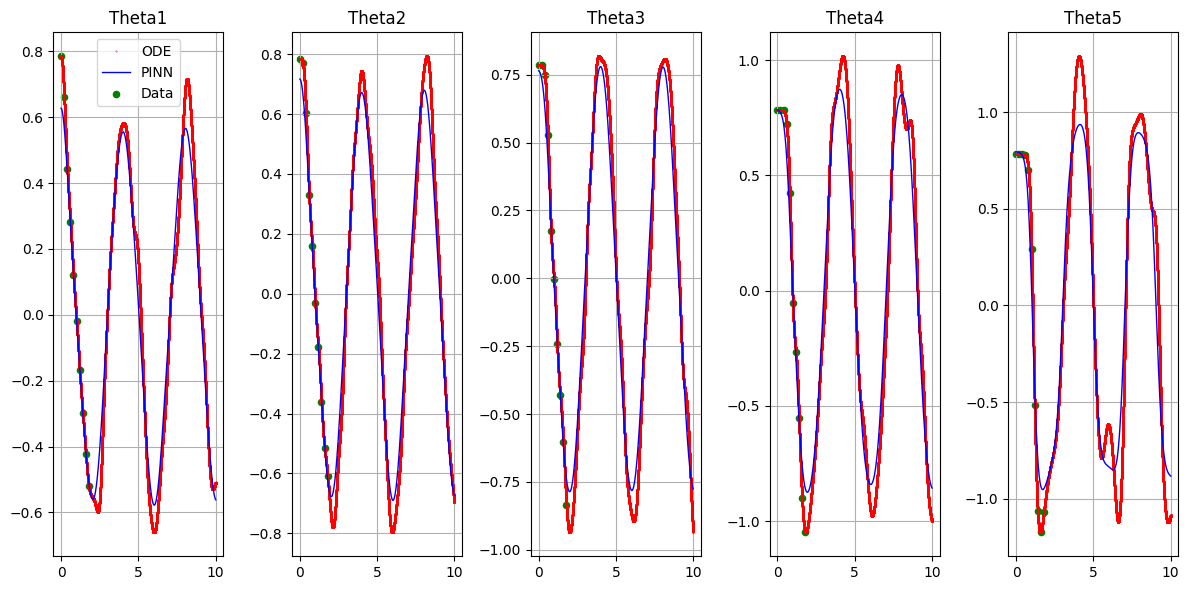

Iteration 21000, Loss_data: 0.007895, Loss_physics: 0.034741, Loss_ic: 0.005844, Loss_energy: 0.000021, Total Loss: 6.474978
Iteration 22000, Loss_data: 0.008486, Loss_physics: 0.168514, Loss_ic: 0.006482, Loss_energy: 0.000016, Total Loss: 20.177507
Iteration 23000, Loss_data: 0.007321, Loss_physics: 0.032357, Loss_ic: 0.005490, Loss_energy: 0.000015, Total Loss: 6.054091
Iteration 24000, Loss_data: 0.006998, Loss_physics: 0.159167, Loss_ic: 0.005238, Loss_energy: 0.000017, Total Loss: 18.605753
Iteration 25000, Loss_data: 0.006806, Loss_physics: 0.131525, Loss_ic: 0.005477, Loss_energy: 0.000013, Total Loss: 15.959033


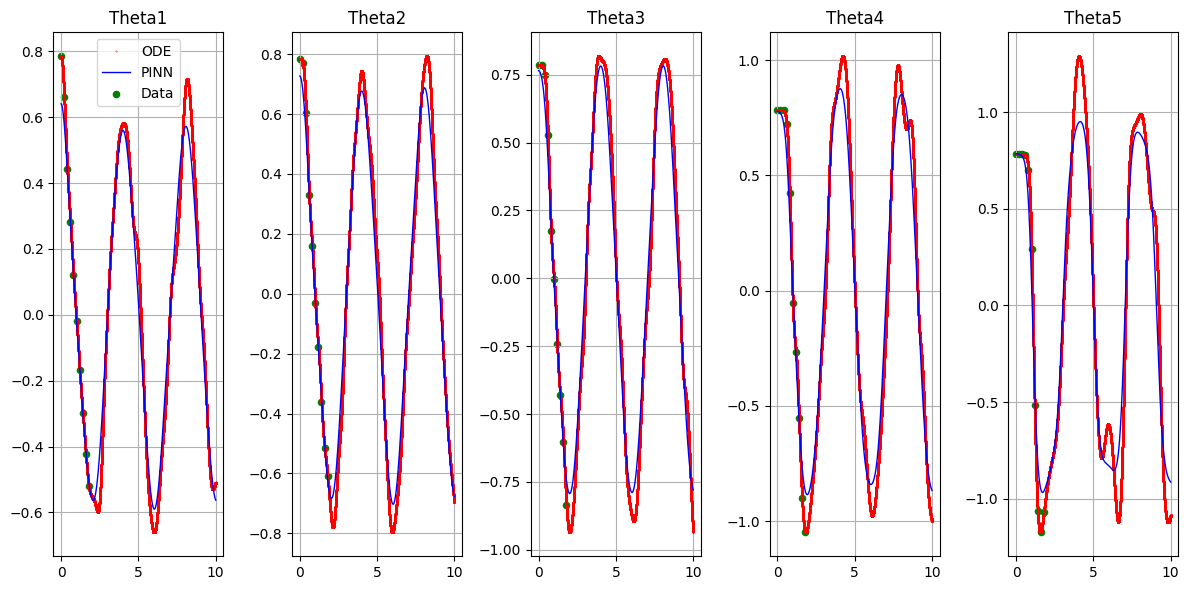

Iteration 26000, Loss_data: 0.006088, Loss_physics: 0.092579, Loss_ic: 0.004349, Loss_energy: 0.000020, Total Loss: 11.493409
Iteration 27000, Loss_data: 0.005920, Loss_physics: 0.627704, Loss_ic: 0.004381, Loss_energy: 0.000047, Total Loss: 65.020096
Iteration 28000, Loss_data: 0.005536, Loss_physics: 0.058076, Loss_ic: 0.004105, Loss_energy: 0.000018, Total Loss: 7.915691
Iteration 29000, Loss_data: 0.004895, Loss_physics: 0.015680, Loss_ic: 0.003568, Loss_energy: 0.000018, Total Loss: 3.400822
Iteration 30000, Loss_data: 0.004401, Loss_physics: 0.022395, Loss_ic: 0.003239, Loss_energy: 0.000014, Total Loss: 3.903149


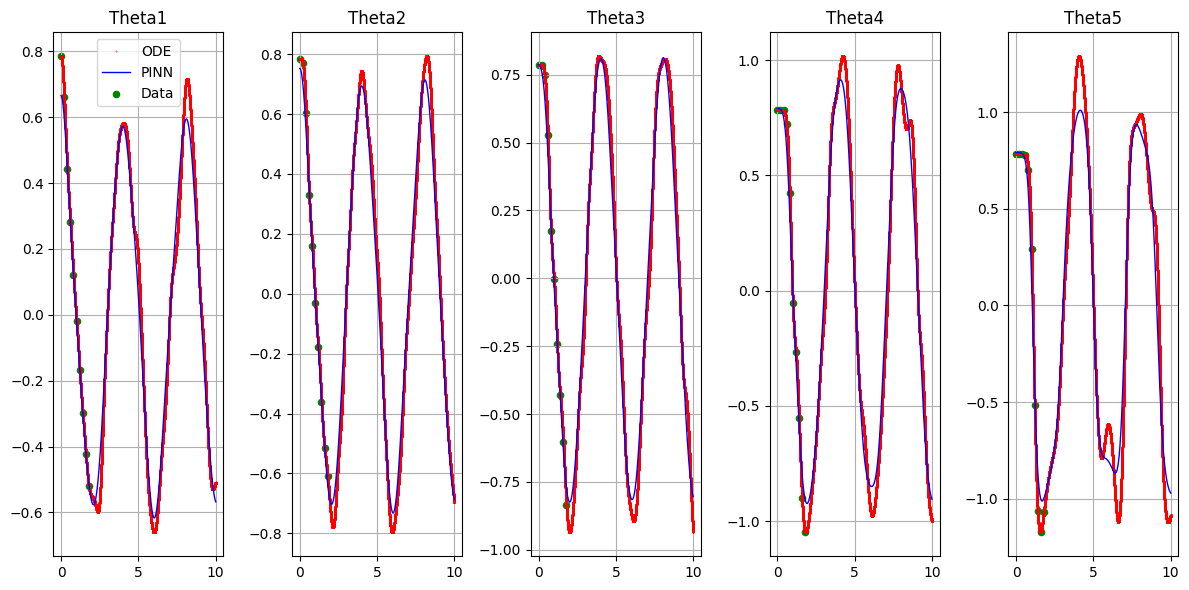

Iteration 31000, Loss_data: 0.004584, Loss_physics: 0.157082, Loss_ic: 0.003299, Loss_energy: 0.000025, Total Loss: 17.403519
Iteration 32000, Loss_data: 0.004482, Loss_physics: 0.023381, Loss_ic: 0.003230, Loss_energy: 0.000014, Total Loss: 3.998095
Iteration 33000, Loss_data: 0.003985, Loss_physics: 0.012518, Loss_ic: 0.002921, Loss_energy: 0.000013, Total Loss: 2.752160
Iteration 34000, Loss_data: 0.003911, Loss_physics: 0.028535, Loss_ic: 0.002856, Loss_energy: 0.000016, Total Loss: 4.320731
Iteration 35000, Loss_data: 0.003773, Loss_physics: 0.013457, Loss_ic: 0.002786, Loss_energy: 0.000016, Total Loss: 2.776470


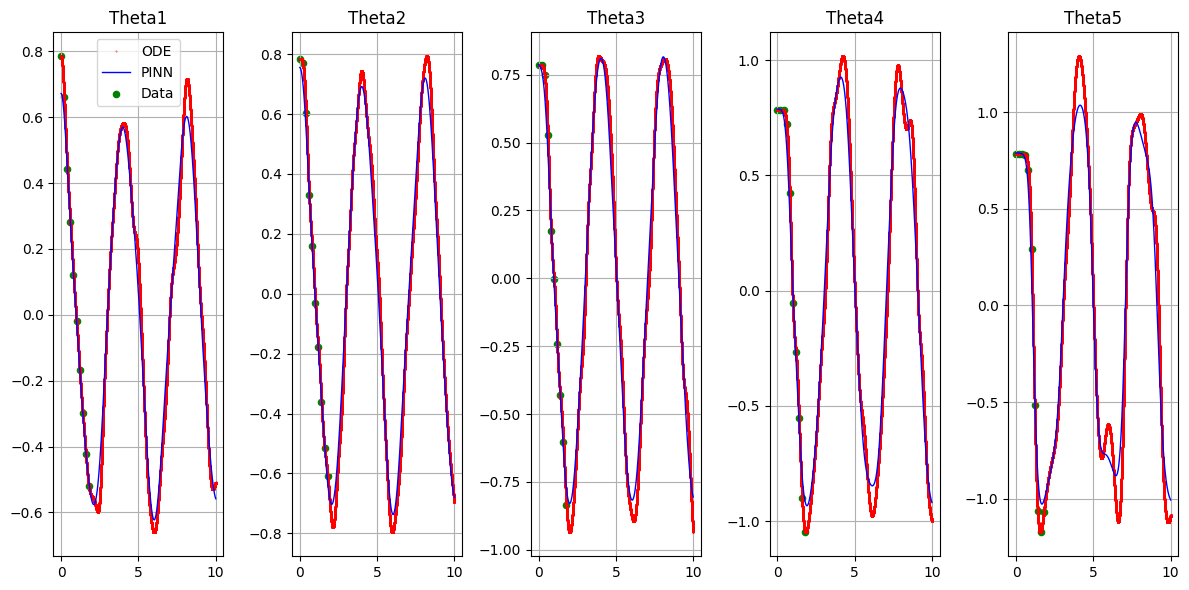

Iteration 36000, Loss_data: 0.003296, Loss_physics: 0.119555, Loss_ic: 0.002587, Loss_energy: 0.000019, Total Loss: 13.281817
Iteration 37000, Loss_data: 0.003261, Loss_physics: 0.358440, Loss_ic: 0.002655, Loss_energy: 0.000028, Total Loss: 37.204021
Iteration 38000, Loss_data: 0.003715, Loss_physics: 0.052215, Loss_ic: 0.002840, Loss_energy: 0.000015, Total Loss: 6.678592
Iteration 39000, Loss_data: 0.003237, Loss_physics: 0.013250, Loss_ic: 0.002427, Loss_energy: 0.000011, Total Loss: 2.570650
Iteration 40000, Loss_data: 0.002923, Loss_physics: 0.029769, Loss_ic: 0.002212, Loss_energy: 0.000010, Total Loss: 4.112080


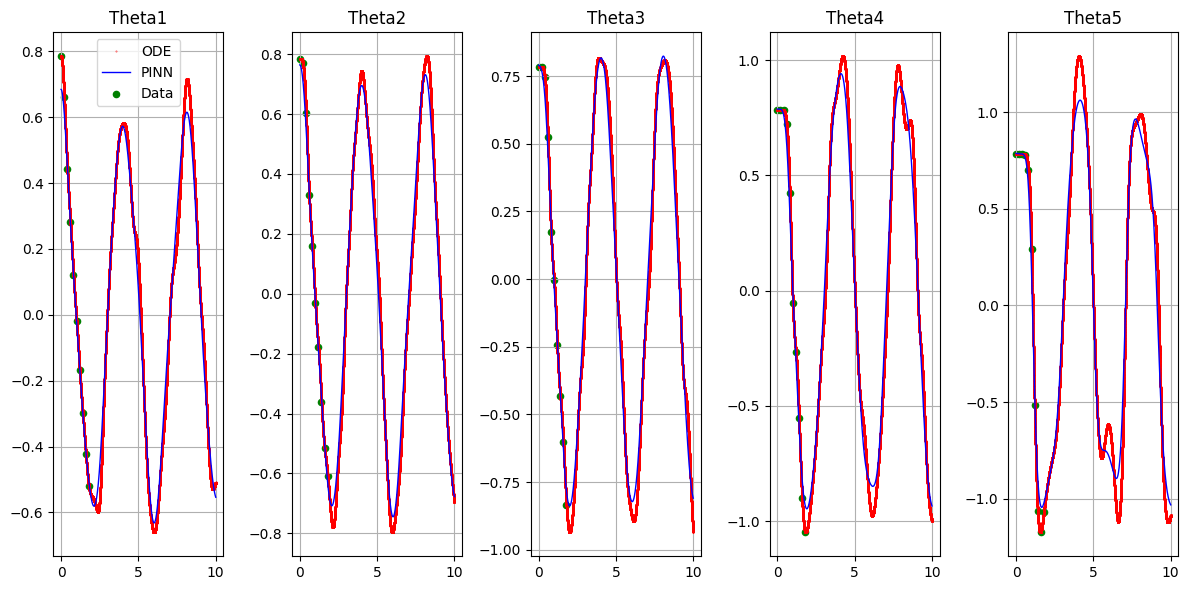

Iteration 41000, Loss_data: 0.002767, Loss_physics: 0.033752, Loss_ic: 0.002122, Loss_energy: 0.000009, Total Loss: 4.464056
Iteration 42000, Loss_data: 0.003135, Loss_physics: 0.088279, Loss_ic: 0.002400, Loss_energy: 0.000021, Total Loss: 10.059026
Iteration 43000, Loss_data: 0.002753, Loss_physics: 0.010916, Loss_ic: 0.002073, Loss_energy: 0.000011, Total Loss: 2.155469
Iteration 44000, Loss_data: 0.002813, Loss_physics: 0.030238, Loss_ic: 0.002137, Loss_energy: 0.000010, Total Loss: 4.120186
Iteration 45000, Loss_data: 0.002639, Loss_physics: 0.127433, Loss_ic: 0.001983, Loss_energy: 0.000014, Total Loss: 13.761310


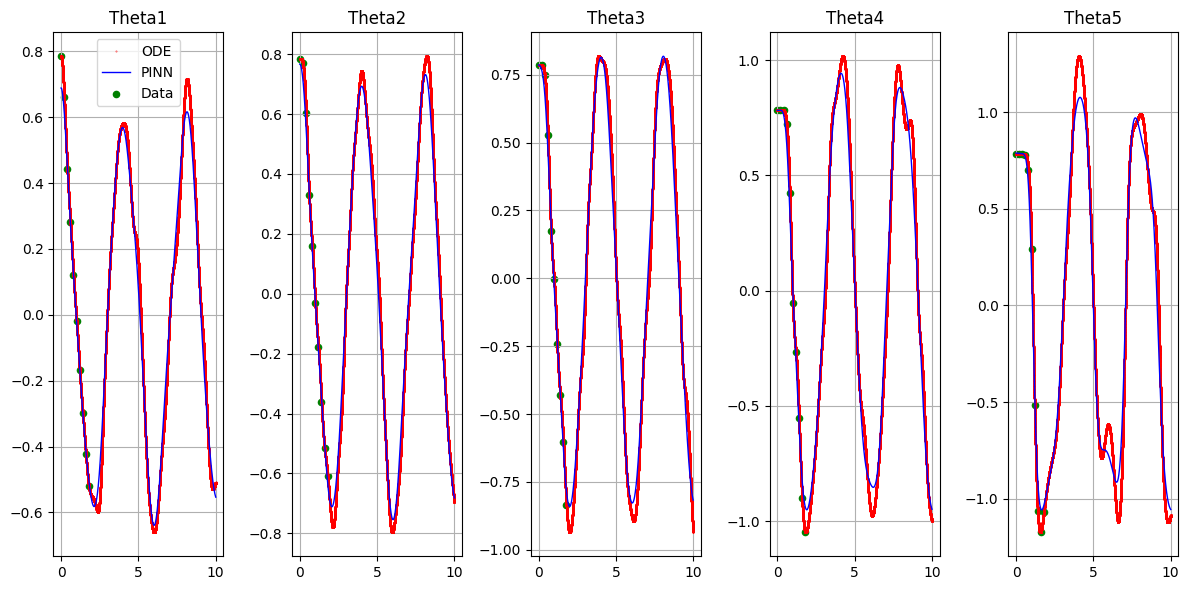

Iteration 46000, Loss_data: 0.002928, Loss_physics: 0.087864, Loss_ic: 0.002168, Loss_energy: 0.000010, Total Loss: 9.899531
Iteration 47000, Loss_data: 0.002472, Loss_physics: 0.016649, Loss_ic: 0.001857, Loss_energy: 0.000008, Total Loss: 2.618285
Iteration 48000, Loss_data: 0.002578, Loss_physics: 0.053483, Loss_ic: 0.001977, Loss_energy: 0.000007, Total Loss: 6.362483
Iteration 49000, Loss_data: 0.002270, Loss_physics: 0.045350, Loss_ic: 0.001690, Loss_energy: 0.000018, Total Loss: 5.402645
Iteration 50000, Loss_data: 0.002283, Loss_physics: 0.035934, Loss_ic: 0.001690, Loss_energy: 0.000016, Total Loss: 4.461217


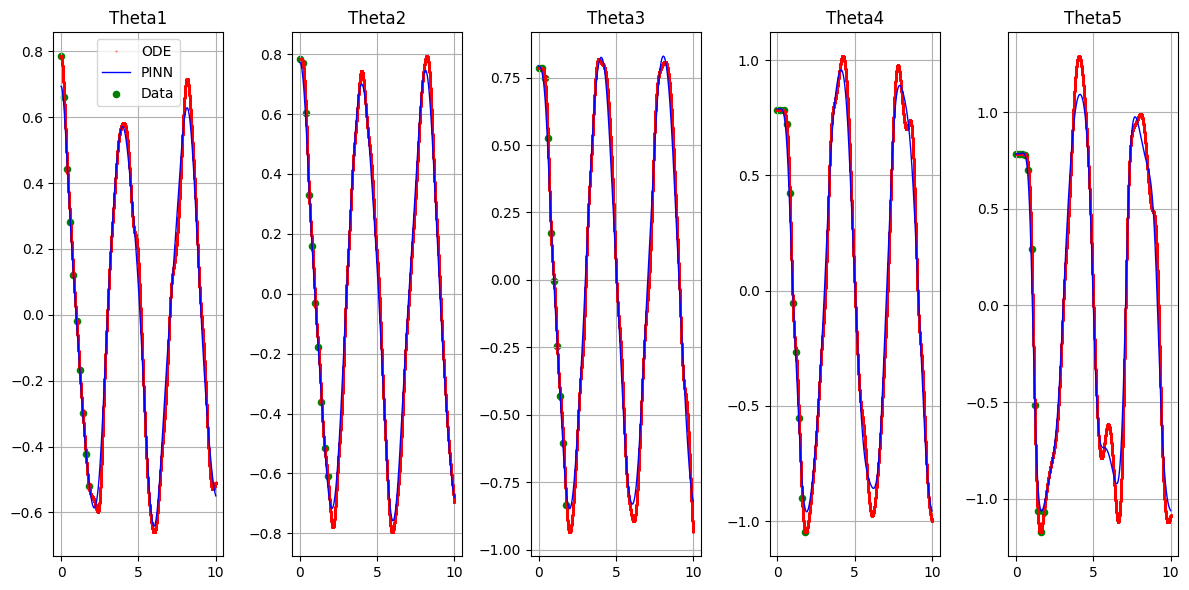

In [49]:
# ===================== DEVICE =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ===================== DATA =====================
x_physics = torch.linspace(
    0,
    end_time,
    1000,
    device=device
).view(-1, 1)

x_physics.requires_grad_(True)

x_data_fp = x_data_fp.to(device)
y_data_fp = y_data_fp.to(device)


# ===================== MODEL =====================
dp_model = FCN(14,5,128,6).to(device)
optimizer = torch.optim.Adam(
    dp_model.parameters(),
    lr=5e-4
)

# ===================== LOSS WEIGHTS =====================
lambda1 = 10       # data
lambda2 = 100       # physics
lambda3 = 500      # IC
lambda4 = 1        # energy


# ===================== LOSS HISTORY =====================
loss_data_history = []
loss_physics_history = []
loss_ic_history = []
loss_energy_history = []
total_loss_history = []
iterations_history = []


# ===================== INITIAL CONDITION POINT =====================
x0 = torch.tensor(
    [[0.0]],
    dtype=torch.float32,
    device=device,
    requires_grad=True
)


# ===================== STOPPING CONDITIONS =====================
target_loss = 10e-2
max_epochs = 50000

i = 0


# ===================== TRAINING =====================
while i < max_epochs:

    optimizer.zero_grad()
    theta_pred = dp_model(x_physics)
    dtheta_list = []

    for k in range(5):

        dtheta_k = torch.autograd.grad(
            theta_pred[:, k:k+1],
            x_physics,
            grad_outputs=torch.ones_like(
                theta_pred[:, k:k+1]
            ),
            create_graph=True,
            retain_graph=True
        )[0]

        dtheta_list.append(dtheta_k)

    dtheta = torch.cat(
        dtheta_list,
        dim=1
    )

    d2theta_list = []

    for k in range(5):

        d2theta_k = torch.autograd.grad(
            dtheta[:, k:k+1],
            x_physics,
            grad_outputs=torch.ones_like(
                dtheta[:, k:k+1]
            ),
            create_graph=True,
            retain_graph=True
        )[0]

        d2theta_list.append(d2theta_k)

    d2theta = torch.cat(
        d2theta_list,
        dim=1
    )


    # =========================================
    # PHYSICS LOSS
    # =========================================
    r = five_pendulum_physics_residuals(

        theta_pred[:, 0:1],
        dtheta[:, 0:1],
        d2theta[:, 0:1],

        theta_pred[:, 1:2],
        dtheta[:, 1:2],
        d2theta[:, 1:2],

        theta_pred[:, 2:3],
        dtheta[:, 2:3],
        d2theta[:, 2:3],

        theta_pred[:, 3:4],
        dtheta[:, 3:4],
        d2theta[:, 3:4],

        theta_pred[:, 4:5],
        dtheta[:, 4:5],
        d2theta[:, 4:5],

        L1, L2, L3, L4, L5,
        m1, m2, m3, m4, m5,
        g
    )


    loss_physics = sum(
        torch.mean(ri ** 2)
        for ri in r
    )


    # =========================================
    # DATA LOSS
    # =========================================
    theta_pred_data = dp_model(
        x_data_fp
    )

    loss_data = torch.mean(
        (theta_pred_data - y_data_fp) ** 2
    )


    # =========================================
    # INITIAL CONDITION
    # =========================================
    y0 = dp_model(x0)

    dy0_list = []

    for k in range(5):

        dy0_k = torch.autograd.grad(
            y0[:, k:k+1],
            x0,
            grad_outputs=torch.ones_like(
                y0[:, k:k+1]
            ),
            create_graph=True,
            retain_graph=True
        )[0]

        dy0_list.append(dy0_k)

    dy0 = torch.cat(
        dy0_list,
        dim=1
    )


    # Initial angles
    init_theta = torch.tensor(
        initial_state_fp[::2],
        dtype=torch.float32,
        device=device
    ).view(1, 5)


    # Initial angular velocities
    init_omega = torch.tensor(
        initial_state_fp[1::2],
        dtype=torch.float32,
        device=device
    ).view(1, 5)


    loss_ic = (
        torch.mean(
            (y0 - init_theta) ** 2
        )
        +
        torch.mean(
            (dy0 - init_omega) ** 2
        )
    )


    # =========================================
    # ENERGY LOSS
    # =========================================
    energy_pred = five_pendulum_energy(

        theta_pred[:, 0:1],dtheta[:, 0:1],
        theta_pred[:, 1:2],dtheta[:, 1:2],
        theta_pred[:, 2:3],dtheta[:, 2:3],
        theta_pred[:, 3:4],dtheta[:, 3:4],
        theta_pred[:, 4:5],dtheta[:, 4:5],
        L1, L2, L3, L4, L5,
        m1, m2, m3, m4, m5,
        g
    )

    energy_initial = energy_pred[0:1].detach()
    energy_scale = torch.mean(torch.abs(energy_initial)).detach() + 1e-6
    loss_energy = torch.mean(((energy_pred - energy_initial)/ energy_scale) ** 2)

    # TOTAL LOSS
    loss = (
        lambda1 * loss_data
        + lambda2 * loss_physics
        + lambda3 * loss_ic
        + lambda4 * loss_energy
    )
    if torch.isnan(loss) or torch.isinf(loss):

        print(
            f"NaN detected at iter {i}"
        )

        break
    loss.backward()
    optimizer.step()
    if loss.item() <= target_loss:

        print(
            f"\nTarget reached at iteration {i+1}"
        )

        print(
            f"Total Loss = {loss.item():.6e}"
        )

        break
    if (i + 1) % 1000 == 0:

        print(
            f"Iteration {i+1}, "
            f"Loss_data: {loss_data.item():.6f}, "
            f"Loss_physics: {loss_physics.item():.6f}, "
            f"Loss_ic: {loss_ic.item():.6f}, "
            f"Loss_energy: {loss_energy.item():.6f}, "
            f"Total Loss: {loss.item():.6f}"
        )

        iterations_history.append(
            i + 1
        )

        loss_data_history.append(
            loss_data.item()
        )

        loss_physics_history.append(
            loss_physics.item()
        )

        loss_ic_history.append(
            loss_ic.item()
        )

        loss_energy_history.append(
            loss_energy.item()
        )

        total_loss_history.append(
            loss.item()
        )
    if (i + 1) % 5000 == 0:

        with torch.no_grad():

            yh_full = dp_model(
                t_torch.to(device)
            ).cpu()


        yh_theta1 = yh_full[:, 0]
        yh_theta2 = yh_full[:, 1]
        yh_theta3 = yh_full[:, 2]
        yh_theta4 = yh_full[:, 3]
        yh_theta5 = yh_full[:, 4]

        plot_result_five_pendulum(
            t_torch.cpu(),
            theta_ode,
            yh_full,
            x_data_fp.cpu(),
            y_data_fp.cpu()
        )

        plt.show()
    i += 1

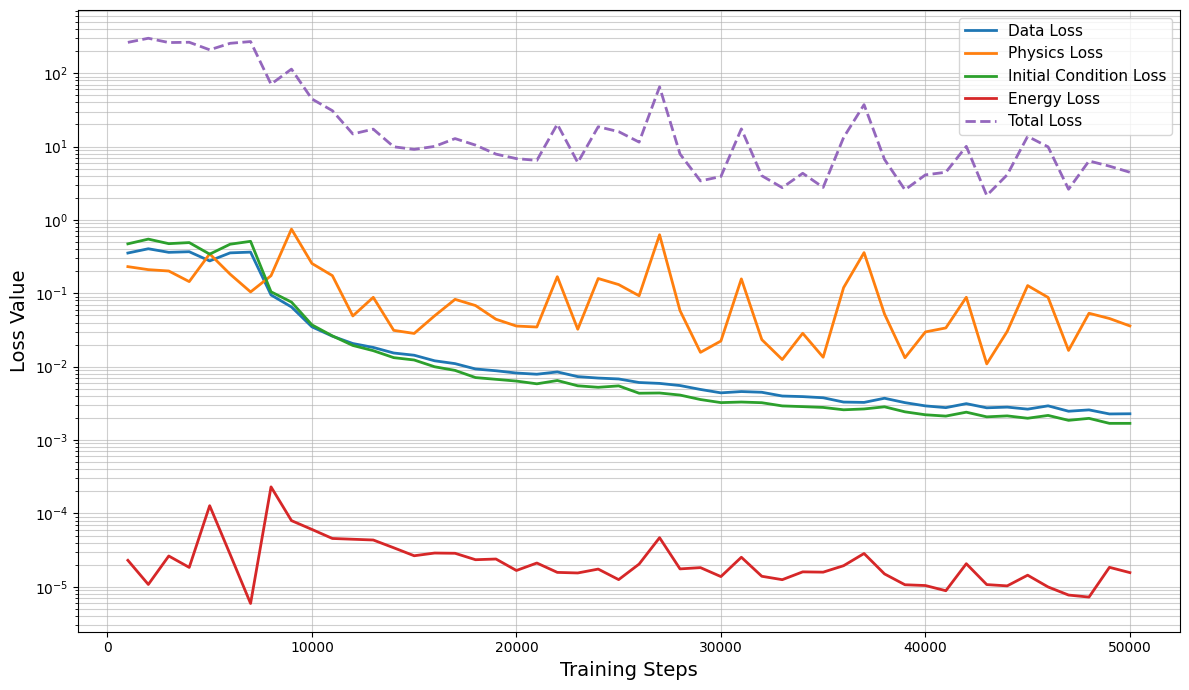

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# training steps
# Use the actual iteration numbers collected during training
training_steps_actual = np.array(iterations_history)

plt.figure(figsize=(12, 7))

# từng thành phần loss
plt.plot(
    training_steps_actual,
    loss_data_history,
    label='Data Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_physics_history,
    label='Physics Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_ic_history,
    label='Initial Condition Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_energy_history,
    label='Energy Loss',
    linewidth=2
)

# loss tổng
plt.plot(
    training_steps_actual,
    total_loss_history,
    '--',
    label='Total Loss',
    linewidth=2
)

plt.xlabel('Training Steps', fontsize=14)
plt.ylabel('Loss Value', fontsize=14)

# log scale
plt.yscale('log')

plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.6)

plt.tight_layout()
plt.show()

In [51]:
# ===== SAVE CHECKPOINT =====
save_path = "five_pendulum_pinn.pt"

torch.save({
    "model_state_dict": dp_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    # ===== training info =====
    "epoch": i,
    "loss": loss.item(),

    # ===== loss history =====
    "loss_data_history": loss_data_history,
    "loss_physics_history": loss_physics_history,
    "loss_ic_history": loss_ic_history,
    "loss_energy_history": loss_energy_history,
    "total_loss_history": total_loss_history,
    "iterations_history": iterations_history,

    # ===== system params =====
    "L": [L1, L2, L3, L4, L5],
    "m": [m1, m2, m3, m4, m5],
    "g": g,

    # ===== training data =====
    "x_data": x_data_fp.cpu(),
    "y_data": y_data_fp.cpu(),

}, save_path)

print("Saved model to", save_path)

Saved model to five_pendulum_pinn.pt


In [52]:
checkpoint = torch.load("five_pendulum_pinn.pt", map_location=device)

dp_model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_iter = checkpoint["epoch"]

loss_data_history = checkpoint["loss_data_history"]
loss_physics_history = checkpoint["loss_physics_history"]
loss_ic_history = checkpoint["loss_ic_history"]
loss_energy_history = checkpoint["loss_energy_history"]
total_loss_history = checkpoint["total_loss_history"]
iterations_history = checkpoint["iterations_history"]

print("Loaded model from iter", start_iter)

Loaded model from iter 50000
